In [4]:
import os
os.listdir("../data")

['HRDataset_v14.csv']

In [7]:
import pandas as pd

df = pd.read_csv("../data/HRDataset_v14.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [8]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
count,311,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,...,311,303.000000,311,311,311.000000,311.000000,311.000000,311,311.000000,311.000000
unique,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21,NaN,9,4,NaN,NaN,NaN,137,NaN,NaN
top,"Adinolfi, Wilson K",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Michael Albert,NaN,Indeed,Fully Meets,NaN,NaN,NaN,1/14/2019,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22,NaN,87,243,NaN,NaN,NaN,18,NaN,NaN
mean,NaN,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,...,NaN,14.570957,NaN,NaN,4.110000,3.890675,1.218650,NaN,0.414791,10.237942
std,NaN,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,...,NaN,8.078306,NaN,NaN,0.789938,0.909241,2.349421,NaN,1.294519,5.852596
min,NaN,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,...,NaN,1.000000,NaN,NaN,1.120000,1.000000,0.000000,NaN,0.000000,1.000000
25%,NaN,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,...,NaN,10.000000,NaN,NaN,3.690000,3.000000,0.000000,NaN,0.000000,5.000000
50%,NaN,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,...,NaN,15.000000,NaN,NaN,4.280000,4.000000,0.000000,NaN,0.000000,10.000000
75%,NaN,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,...,NaN,19.000000,NaN,NaN,4.700000,5.000000,0.000000,NaN,0.000000,15.000000


In [51]:
drop_cols = [
    'Employee_Name', 'EmpID', 'EmployeeID',
    'ManagerName', 'ManagerID',
    'DateofTermination', 'TermReason', 'EmploymentStatus',
    'DOB', 'DateofHire', 'LastPerformanceReview_Date',
    'DateofLastPromotion', 'DateofLastWarning',
    'Address', 'City', 'Zip',
    'PerfScoreID', 'EmpStatusID', 'DeptID'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

X = df.drop(columns=['Termd'])
y = df['Termd']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=5000, solver='liblinear'))
])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

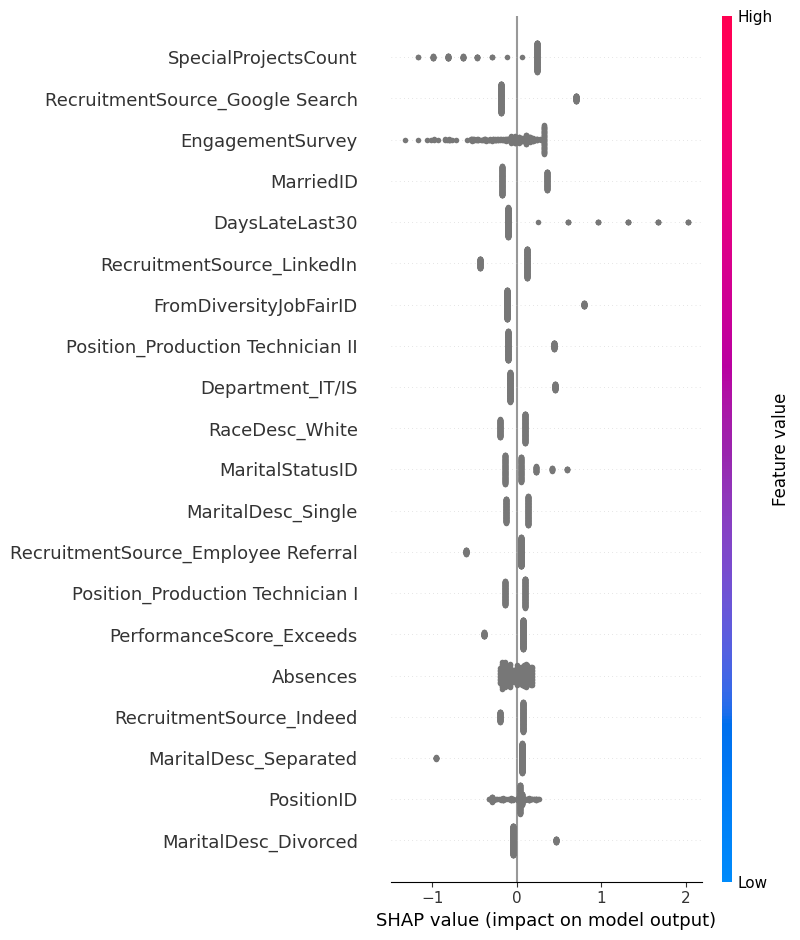

In [57]:
import shap

X_train_transformed = pipeline.named_steps['preprocess'].transform(X_train)

explainer = shap.Explainer(pipeline.named_steps['model'], X_train_transformed)
shap_values = explainer(X_train_transformed)

ohe = pipeline.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_features)

feature_names = list(numeric_features) + list(ohe_features)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

In [58]:
df_test = X_test.copy()
df_test['Termd_true'] = y_test
df_test['Termd_pred'] = y_pred

df_test.groupby('Sex')[['Termd_true','Termd_pred']].mean()

,Termd_true,Termd_pred
Sex,,
F,0.323529,0.294118
M,0.344828,0.344828


In [59]:
dp_diff = df_test.groupby('Sex')['Termd_pred'].mean().diff().iloc[-1]
dp_diff

np.float64(0.050709939148073035)

In [60]:
from sklearn.metrics import recall_score

recall_scores = []
for label in [0, 1]:
    y_true_label = (y_test == label).astype(int)
    y_pred_label = (y_pred == label).astype(int)
    score = recall_score(y_true_label, y_pred_label)
    recall_scores.append(score)

avg_recall = sum(recall_scores) / len(recall_scores)
avg_recall

0.9761904761904762

In [61]:
from sklearn.metrics import recall_score

def safe_recall(df, group_col, label):
    group = df[df[group_col] == label]
    if group['Termd_true'].sum() == 0:
        return None  # No positives, recall undefined
    return recall_score(group['Termd_true'], group['Termd_pred'])

recall_f = safe_recall(df_test, 'Sex', 'F')
recall_m = safe_recall(df_test, 'Sex', 'M')

recall_f, recall_m, None if recall_f is None or recall_m is None else recall_f - recall_m

(0.9090909090909091, None, None)

In [62]:
df_test.groupby('RaceDesc')[['Termd_true','Termd_pred']].mean()

,Termd_true,Termd_pred
RaceDesc,,
American Indian or Alaska Native,0.000000,0.000000
Asian,0.428571,0.428571
Black or African American,0.300000,0.250000
Two or more races,0.333333,0.333333
White,0.343750,0.343750


In [63]:
import joblib
joblib.dump(pipeline, "trusted_hr_ai_model.pkl")

['trusted_hr_ai_model.pkl']